# Pandas: от таблицы к аналитическому выводу

На этом занятии pandas рассматривается не как набор разрозненных методов, а как рабочий инструмент аналитика, разработчика и исследователя данных. Мы будем идти от простых таблиц к вопросам, которые похожи на реальные: где больше городов-миллионников, какие регионы дают больше заказов, какие категории растут, где стоит искать проблемы с доставкой.

Структура занятия:

1. зачем нужен pandas и какие задачи он закрывает;
2. `Series`, `DataFrame`, `Index`;
3. чтение, первичный осмотр и выборка данных;
4. пропуски, выравнивание и индексы;
5. объединение таблиц через `merge`;
6. агрегации, `groupby` и `pivot_table`;
7. даты и временные ряды;
8. как pandas помогает в машинном обучении;
9. визуализация.

## Зачем нужен pandas

В реальных задачах данные редко приходят в виде аккуратного массива чисел. Чаще это CSV из внутренней системы, выгрузка заказов, лог событий, таблица клиентов, справочник регионов или результат SQL-запроса. В таких данных бывают пропуски, разные типы, текстовые категории, даты, дубликаты и несколько таблиц, которые нужно соединить.

Pandas нужен как раз для этого слоя работы:

- быстро прочитать данные из файла или базы;
- понять структуру: какие колонки есть, где пропуски, какие типы;
- отфильтровать нужные строки и посчитать новые признаки;
- объединить несколько источников;
- получить сводные показатели и графики;
- подготовить данные для отчёта, модели машинного обучения или загрузки в другую систему.

In [ ]:
# Если pandas или matplotlib не установлены в окружении, раскомментируйте строку ниже.
# %pip install pandas matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (10, 5)

## Основные структуры данных

На первом уровне можно думать так:

- `Series` — один столбец данных с индексом;
- `DataFrame` — таблица, где каждый столбец является `Series`;
- `Index` — набор меток строк, по которым pandas умеет быстро выравнивать и соединять данные.

Главное отличие от обычного списка или массива NumPy: у данных появляется смысловая разметка. Мы можем обращаться не только к “третьему элементу”, но и к строке с датой, городом или идентификатором заказа.

### Series

`Series` полезен, когда есть одна измеряемая величина: дневная выручка, температура по датам, число заказов по городам, баланс пользователя. Индекс помогает не потерять, к чему относится каждое значение.

In [3]:
daily_revenue = pd.Series(
    [120_500, 134_900, 98_200, 155_700],
    index=pd.to_datetime(["2025-04-01", "2025-04-02", "2025-04-03", "2025-04-04"]),
    name="revenue",
)
daily_revenue

2025-04-01    120500
2025-04-02    134900
2025-04-03     98200
2025-04-04    155700
Name: revenue, dtype: int64

In [4]:
daily_revenue.index

DatetimeIndex(['2025-04-01', '2025-04-02', '2025-04-03', '2025-04-04'], dtype='datetime64[ns]', freq=None)

In [5]:
daily_revenue.loc["2025-04-02"]

134900

`Series` похож на словарь Python: ключом может быть дата, строка, число или другая метка. В отличие от словаря, pandas сохраняет порядок, умеет считать статистики и выполнять векторные операции сразу над всеми значениями.

In [6]:
capitals = pd.Series({"Russia": "Moscow", "China": "Beijing", "Brazil": "Brasilia"})
capitals

Russia      Moscow
China      Beijing
Brazil    Brasilia
dtype: object

### DataFrame

`DataFrame` — основная рабочая форма данных в pandas. Так обычно выглядят заказы, пользователи, транзакции, города, товары, события в приложении. Каждая строка — наблюдение, каждый столбец — признак.

In [7]:
orders_demo = pd.DataFrame(
    {
        "order_id": [101, 102, 103],
        "city": ["Москва", "Казань", "Новосибирск"],
        "category": ["Электроника", "Одежда", "Дом и ремонт"],
        "revenue": [58_000, 4_500, 12_900],
        "status": ["paid", "paid", "returned"],
    }
)
orders_demo

,order_id,city,category,revenue,status
0,101,Москва,Электроника,58000,paid
1,102,Казань,Одежда,4500,paid
2,103,Новосибирск,Дом и ремонт,12900,returned


In [8]:
orders_demo.columns

Index(['order_id', 'city', 'category', 'revenue', 'status'], dtype='object')

In [9]:
orders_demo["revenue"]

0    58000
1     4500
2    12900
Name: revenue, dtype: int64

In [10]:
orders_demo.loc[0]

order_id            101
city             Москва
category    Электроника
revenue           58000
status             paid
Name: 0, dtype: object

Важно: `df["column"]` выбирает столбец, а не строку. Для строк используем `.loc` по метке индекса или `.iloc` по позиции. Это правило снижает путаницу в больших таблицах, где столбцов может быть десятки или сотни.

## Чтение и первичный осмотр данных

Первый этап почти любой работы с данными — понять, что лежит в файле. В этом занятии используем локальный датасет городов России. Население указано в тысячах человек.

In [11]:
towns = pd.read_csv("towns.csv")
towns.head()

,city,population,lat,lon,region_name,region_name_ao,region_iso_code,federal_district,okato,oktmo,kladr_id,fias_id,place_id
0,Алейск,29.0,52.492251,82.779361,Алтайский край,NaN,RU-ALT,Сибирский,1403000000,1703000001,2200000200000,ae716080-f27b-40b6-a555-cf8b518e849e,257210632.0
1,Барнаул,632.4,53.347997,83.779806,Алтайский край,NaN,RU-ALT,Сибирский,1401000000,1701000001,2200000100000,d13945a8-7017-46ab-b1e6-ede1e89317ad,258390190.0
2,Белокуриха,15.2,51.996152,84.983960,Алтайский край,NaN,RU-ALT,Сибирский,1404000000,1704000001,2200000300000,e4edca96-9b86-4cac-8c7f-cc93d9ba4cd1,258169961.0
3,Бийск,199.5,52.539386,85.213845,Алтайский край,NaN,RU-ALT,Сибирский,1405000000,1705000001,2200000400000,52f876f6-cb1d-4f23-a22f-b692609fc1e0,258937159.0
4,Горняк,12.3,50.997962,81.464336,Алтайский край,NaN,RU-ALT,Сибирский,1225501000,1625101001,2202700100000,094b3627-2699-4782-8492-4d82aac71958,259062368.0


In [12]:
towns.shape

(1117, 13)

In [13]:
towns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117 entries, 0 to 1116
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              1117 non-null   object 
 1   population        1117 non-null   float64
 2   lat               1117 non-null   float64
 3   lon               1117 non-null   float64
 4   region_name       1117 non-null   object 
 5   region_name_ao    25 non-null     object 
 6   region_iso_code   1117 non-null   object 
 7   federal_district  1117 non-null   object 
 8   okato             1117 non-null   int64  
 9   oktmo             1117 non-null   int64  
 10  kladr_id          1117 non-null   int64  
 11  fias_id           1117 non-null   object 
 12  place_id          1111 non-null   float64
dtypes: float64(4), int64(3), object(6)
memory usage: 113.6+ KB


In [14]:
towns.describe()

,population,lat,lon,okato,oktmo,kladr_id,place_id
count,1117.000000,1117.000000,1117.000000,1.117000e+03,1.117000e+03,1.117000e+03,1.111000e+03
mean,92.050132,54.553149,54.812589,4.743828e+10,4.641039e+10,7.431626e+13,2.198946e+08
std,440.594984,5.226445,27.874005,2.689454e+10,2.764108e+10,2.333690e+15,7.025641e+07
min,0.400000,42.058966,19.914057,1.214501e+09,4.630102e+06,1.000001e+11,1.934060e+05
25%,12.800000,52.144962,37.861855,2.522851e+10,2.275800e+10,2.900000e+12,1.520083e+08
50%,26.000000,55.150801,43.919154,4.645600e+10,4.674100e+10,4.700500e+12,2.586358e+08
75%,59.200000,57.145108,60.107757,6.843000e+10,6.671000e+10,6.200000e+12,2.590792e+08
max,12655.100000,69.701666,177.501542,9.940100e+10,9.970100e+10,7.800000e+16,3.266881e+08


Методы первичного осмотра отвечают на практические вопросы:

- `head()` — как выглядят строки и названия колонок;
- `shape` — сколько данных и насколько большой датасет;
- `info()` — какие типы у колонок и где есть пропуски;
- `describe()` — диапазоны, средние значения и выбросы в числовых колонках.

В реальной работе этот этап часто экономит часы: можно сразу заметить, что дата прочиталась как строка, число как текст, а половина значений в колонке отсутствует.

## Выборка строк и столбцов

Выборка — базовый навык для ответов на конкретные вопросы: “покажи города-миллионники”, “найди заказы дороже 50 тысяч”, “оставь только нужные колонки для отчёта”.

In [15]:
towns = towns.assign(population_mln=towns["population"] / 1000)

towns[["city", "region_name", "federal_district", "population_mln"]].head()

,city,region_name,federal_district,population_mln
0,Алейск,Алтайский край,Сибирский,0.0290
1,Барнаул,Алтайский край,Сибирский,0.6324
2,Белокуриха,Алтайский край,Сибирский,0.0152
3,Бийск,Алтайский край,Сибирский,0.1995
4,Горняк,Алтайский край,Сибирский,0.0123


In [16]:
million_cities = towns.loc[
    towns["population"] >= 1000,
    ["city", "region_name", "federal_district", "population_mln"],
].sort_values("population_mln", ascending=False)

million_cities

,city,region_name,federal_district,population_mln
412,Москва,Москва,Центральный,12.6551
839,Санкт-Петербург,Санкт-Петербург,Северо-Западный,5.3843
549,Новосибирск,Новосибирская область,Сибирский,1.6256
885,Екатеринбург,Свердловская область,Уральский,1.4937
771,Казань,Республика Татарстан,Приволжский,1.2574
521,Нижний Новгород,Нижегородская область,Приволжский,1.2522
1085,Челябинск,Челябинская область,Уральский,1.1967
835,Самара,Самарская область,Приволжский,1.1567
558,Омск,Омская область,Сибирский,1.1545
810,Ростов-на-Дону,Ростовская область,Южный,1.1379


In [17]:
towns.query("100 <= population < 500")[
    ["city", "region_name", "population_mln"]
].sort_values("population_mln", ascending=False).head(10)

,city,region_name,population_mln
1100,Чебоксары,Чувашская Республика,0.4976
206,Калининград,Калининградская область,0.4893
1005,Тула,Тульская область,0.4752
361,Курск,Курская область,0.4530
953,Ставрополь,Ставропольский край,0.4507
320,Сочи,Краснодарский край,0.4436
671,Улан-Удэ,Республика Бурятия,0.4391
981,Тверь,Тверская область,0.4251
1072,Магнитогорск,Челябинская область,0.4133
156,Иваново,Ивановская область,0.4046


In [ ]:
towns.loc[towns["city"].eq("Казань"), ["city", "region_name", "population_mln"]]

In [ ]:
towns.iloc[:5, :5]

`.loc` лучше читать как “выбери по смысловым меткам или условиям”, `.iloc` — “выбери по номеру строки и столбца”. В продуктовой аналитике чаще используется `.loc`, потому что мы фильтруем по условиям: дата, город, сегмент, статус заказа.

## Создание новых признаков

Часто исходных колонок недостаточно. Мы добавляем признаки, чтобы данные стали удобнее для анализа: возраст клиента из даты рождения, месяц заказа из даты, группу города по населению, маржу из выручки и себестоимости.

In [18]:
bins = [0, 50, 100, 250, 500, 1000, np.inf]
labels = ["до 50 тыс.", "50-100 тыс.", "100-250 тыс.", "250-500 тыс.", "500 тыс.-1 млн", "1 млн+"]

towns = towns.assign(
    population_group=pd.cut(towns["population"], bins=bins, labels=labels, right=False)
)

towns[["city", "population_mln", "population_group"]].sort_values(
    "population_mln", ascending=False
).head(10)

,city,population_mln,population_group
412,Москва,12.6551,1 млн+
839,Санкт-Петербург,5.3843,1 млн+
549,Новосибирск,1.6256,1 млн+
885,Екатеринбург,1.4937,1 млн+
771,Казань,1.2574,1 млн+
521,Нижний Новгород,1.2522,1 млн+
1085,Челябинск,1.1967,1 млн+
835,Самара,1.1567,1 млн+
558,Омск,1.1545,1 млн+
810,Ростов-на-Дону,1.1379,1 млн+


## Операции, выравнивание и пропуски

Pandas автоматически выравнивает данные по индексам. Это очень удобно, когда мы сравниваем план и факт, соединяем метрики из разных источников или считаем изменения между периодами. Но именно из-за выравнивания появляются `NaN`, если значение есть в одной таблице и отсутствует в другой.

In [19]:
plan = pd.Series(
    {"Москва": 13_000, "Санкт-Петербург": 5_700, "Казань": 1_300, "Иннополис": 10},
    name="plan_thousand",
)
fact = towns.set_index("city")["population"].loc[
    ["Москва", "Санкт-Петербург", "Казань", "Екатеринбург"]
].rename("fact_thousand")

comparison = pd.concat([plan, fact], axis=1)
comparison["delta"] = comparison["fact_thousand"] - comparison["plan_thousand"]
comparison

,plan_thousand,fact_thousand,delta
Москва,13000.0,12655.1,-344.9
Санкт-Петербург,5700.0,5384.3,-315.7
Казань,1300.0,1257.4,-42.6
Иннополис,10.0,NaN,NaN
Екатеринбург,NaN,1493.7,NaN


In [20]:
comparison.fillna({"plan_thousand": 0, "fact_thousand": 0})

,plan_thousand,fact_thousand,delta
Москва,13000.0,12655.1,-344.9
Санкт-Петербург,5700.0,5384.3,-315.7
Казань,1300.0,1257.4,-42.6
Иннополис,10.0,0.0,NaN
Екатеринбург,0.0,1493.7,NaN


Пропуски не всегда ошибка. Иногда это важный сигнал: пользователь не заполнил поле, регион не нашёлся в справочнике, заказ ещё не доставлен, событие не пришло из трекинга. Поэтому pandas даёт несколько стратегий:

- найти пропуски: `.isna()`, `.notna()`;
- удалить неполные строки: `.dropna()`;
- заполнить значением или правилом: `.fillna()`;
- отдельно разобрать, почему данные пропали.

In [ ]:
towns.isna().mean().sort_values(ascending=False).head(6)

In [ ]:
towns["region_name_ao"].fillna("нет автономного округа").head()

## Индексы и MultiIndex

Индекс — не просто номер строки. Это способ сказать pandas, какая колонка является ключом. Например, город можно сделать индексом, чтобы быстро доставать строку по названию. Составной индекс удобен, когда данные естественно вложены: федеральный округ → регион → город.

In [21]:
towns_by_city = towns.set_index("city").sort_index()
towns_by_city.loc[["Москва", "Казань", "Екатеринбург"], ["region_name", "population_mln"]]

,region_name,population_mln
city,,
Москва,Москва,12.6551
Казань,Республика Татарстан,1.2574
Екатеринбург,Свердловская область,1.4937


In [22]:
towns_hierarchy = towns.set_index(["federal_district", "region_name", "city"]).sort_index()
towns_hierarchy.loc[("Сибирский", "Алтайский край")][["population_mln", "lat", "lon"]].head()

,population_mln,lat,lon
city,,,
Алейск,0.0290,52.492251,82.779361
Барнаул,0.6324,53.347997,83.779806
Белокуриха,0.0152,51.996152,84.983960
Бийск,0.1995,52.539386,85.213845
Горняк,0.0123,50.997962,81.464336


In [23]:
towns_hierarchy.loc["Сибирский"][["population_mln"]].sort_values(
    "population_mln", ascending=False
).head(10)

population_mln
region_name                   city                       
Новосибирская область         Новосибирск          1.6256
Омская область                Омск                 1.1545
Красноярский край             Красноярск           1.0938
Алтайский край                Барнаул              0.6324
Иркутская область             Иркутск              0.6236
Томская область               Томск                0.5766
Кемеровская область - Кузбасс Кемерово             0.5564
                              Новокузнецк          0.5494
Иркутская область             Братск               0.2263
                              Ангарск              0.2246

MultiIndex особенно полезен в отчётах и витринах данных: можно хранить показатели сразу по нескольким уровням детализации и быстро проваливаться из общего уровня в частный.

## Объединение таблиц: `merge`

Одна таблица редко отвечает на все вопросы. Данные о городах можно обогатить справочником регионов: площадью региона и долей территории страны. В бизнесовых задачах это то же самое, что соединить заказы с пользователями, товары с категориями, события с рекламными кампаниями.

In [24]:
regions = pd.read_csv("regions.csv", sep=";", decimal=",").rename(
    columns={
        "Субъект": "region_name",
        "округ": "federal_district",
        "площадь": "region_area",
        "процент": "region_size_percent",
    }
)

regions.head()

,region_name,region_area,region_size_percent,federal_district
0,Республика Саха (Якутия),3083523,18.01,Дальневосточный
1,Красноярский край,2366797,13.82,Сибирский
2,Тюменская область с ХМАО и ЯНАО,1464173,8.55,Уральский
3,Хабаровский край,787633,4.60,Дальневосточный
4,Иркутская область,774846,4.52,Сибирский


Перед объединением нужно проверить ключи. Даже небольшие отличия в названиях ломают join: сокращённое название региона, другой тип тире, уточнение “с автономными округами”. Это обычная часть работы с реальными справочниками.

In [25]:
region_aliases = {
    "Кабардино-Балкария": "Кабардино-Балкарская Республика",
    "Карачаево-Черкесия": "Карачаево-Черкесская Республика",
    "Кемеровская область": "Кемеровская область - Кузбасс",
    "Тюменская область с ХМАО и ЯНАО": "Тюменская область",
    "Архангельская область включая НАО": "Архангельская область",
    "Республика Северная Осетия — Алания": "Республика Северная Осетия – Алания",
}

regions["region_name"] = regions["region_name"].replace(region_aliases)

In [26]:
towns_extended = towns.merge(
    regions,
    how="left",
    on=["region_name", "federal_district"],
    validate="many_to_one",
    indicator=True,
)

towns_extended["_merge"].value_counts()

_merge
both          1117
left_only        0
right_only       0
Name: count, dtype: int64

In [27]:
towns_extended.loc[
    towns_extended["region_area"].isna(),
    ["region_name", "federal_district"],
].drop_duplicates()

,region_name,federal_district


`validate="many_to_one"` защищает от случайного размножения строк. Если справочник регионов содержит несколько строк на один ключ, pandas остановит выполнение и покажет проблему. В production-аналитике это важная страховка: иначе одна ошибка в справочнике может незаметно раздуть выручку или количество пользователей.

## Агрегирование и группировка

Агрегация отвечает на вопрос “что происходит в целом?”. Вместо тысячи строк мы получаем несколько чисел: сумма выручки, средний чек, число городов, доля возвратов, медианное время доставки.

`groupby` работает в три шага:

1. разбивает данные на группы;
2. применяет функцию к каждой группе;
3. собирает результат обратно в таблицу.

In [29]:
district_stats = (
    towns_extended.groupby("federal_district")
    .agg(
        city_count=("city", "count"),
        urban_population_mln=("population_mln", "sum"),
        avg_city_population_thousand=("population", "mean"),
        median_city_population_thousand=("population", "median"),
    )
    .round(2)
    .sort_values("urban_population_mln", ascending=False)
)

district_stats

,city_count,urban_population_mln,avg_city_population_thousand,median_city_population_thousand
federal_district,,,,
Центральный,304,30.82,101.38,21.80
Приволжский,200,19.71,98.57,28.05
Сибирский,114,11.68,102.46,29.55
Северо-Западный,148,11.21,75.76,15.15
Южный,96,9.99,104.08,39.20
Уральский,115,9.60,83.47,32.60
Дальневосточный,82,5.11,62.37,20.15
Северо-Кавказский,58,4.69,80.82,38.95


In [30]:
largest_city_idx = towns_extended.groupby("federal_district")["population"].idxmax()

towns_extended.loc[
    largest_city_idx,
    ["federal_district", "city", "region_name", "population_mln"],
].sort_values("population_mln", ascending=False)

,federal_district,city,region_name,population_mln
412,Центральный,Москва,Москва,12.6551
839,Северо-Западный,Санкт-Петербург,Санкт-Петербург,5.3843
549,Сибирский,Новосибирск,Новосибирская область,1.6256
885,Уральский,Екатеринбург,Свердловская область,1.4937
771,Приволжский,Казань,Республика Татарстан,1.2574
810,Южный,Ростов-на-Дону,Ростовская область,1.1379
1057,Дальневосточный,Хабаровск,Хабаровский край,0.6164
679,Северо-Кавказский,Махачкала,Республика Дагестан,0.6035


`pivot_table` делает сводную таблицу: строки и столбцы становятся измерениями, а внутри лежит агрегированная метрика. Это близко к тому, как устроены отчёты в Excel, BI-системах и внутренних аналитических панелях.

In [31]:
city_matrix = pd.pivot_table(
    towns_extended,
    values="city",
    index="federal_district",
    columns="population_group",
    aggfunc="count",
    fill_value=0,
)

city_matrix

population_group,до 50 тыс.,50-100 тыс.,100-250 тыс.,250-500 тыс.,500 тыс.-1 млн,1 млн+
federal_district,,,,,,
Дальневосточный,63,7,7,3,2,0
Приволжский,133,34,16,4,8,5
Северо-Западный,123,14,4,6,0,1
Северо-Кавказский,33,11,10,3,1,0
Сибирский,77,18,11,0,5,3
Уральский,81,17,9,5,1,2
Центральный,227,31,26,14,4,2
Южный,57,18,12,4,3,2


## Датасет заказов для агрегаций

Для агрегаций, сводных таблиц и дат возьмём более жизненный пример: синтетическую выгрузку заказов маркетплейса по городам. В ней есть дата заказа, город, округ, категория, канал продаж, цена, скидка, выручка, срок доставки, возврат и оценка.

Такие таблицы похожи на реальные выгрузки из CRM, биллинга или аналитического хранилища. По ним считают выручку, средний чек, эффективность каналов, возвраты, сезонность и проблемы операций.

In [32]:
orders = pd.read_csv("marketplace_orders.csv", parse_dates=["order_date"])
orders.head()

,order_id,order_date,city,region_name,federal_district,category,channel,quantity,price,discount,revenue,delivery_days,returned,rating
0,ORD-2025-02484,2025-01-01,Чегем,Кабардино-Балкарская Республика,Северо-Кавказский,Услуги,web,2,4230,0.00,8460,8,False,4.6
1,ORD-2025-05758,2025-01-01,Сосногорск,Республика Коми,Северо-Западный,Детские товары,mobile_app,1,5240,0.00,5240,2,False,4.6
2,ORD-2025-04341,2025-01-01,Дно,Псковская область,Северо-Западный,Одежда,call_center,1,4070,0.05,3866,4,False,4.9
3,ORD-2025-05937,2025-01-01,Долгопрудный,Московская область,Центральный,Одежда,web,1,4420,0.10,3978,3,False,4.7
4,ORD-2025-02278,2025-01-01,Жигулевск,Самарская область,Приволжский,Авто,mobile_app,2,6190,0.00,12380,2,False,4.7


In [33]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          6000 non-null   object        
 1   order_date        6000 non-null   datetime64[ns]
 2   city              6000 non-null   object        
 3   region_name       6000 non-null   object        
 4   federal_district  6000 non-null   object        
 5   category          6000 non-null   object        
 6   channel           6000 non-null   object        
 7   quantity          6000 non-null   int64         
 8   price             6000 non-null   int64         
 9   discount          6000 non-null   float64       
 10  revenue           6000 non-null   int64         
 11  delivery_days     6000 non-null   int64         
 12  returned          6000 non-null   bool          
 13  rating            6000 non-null   float64       
dtypes: bool(1), datetime64[n

In [34]:
orders.describe()

,order_date,quantity,price,discount,revenue,delivery_days,rating
count,6000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2025-03-31 04:25:40.800000,1.287833,10630.240000,0.030875,13234.679000,3.824000,4.533183
min,2025-01-01 00:00:00,1.000000,850.000000,0.000000,1110.000000,1.000000,2.400000
25%,2025-02-13 00:00:00,1.000000,4480.000000,0.000000,4932.000000,3.000000,4.300000
50%,2025-03-30 00:00:00,1.000000,7690.000000,0.000000,9049.000000,4.000000,4.600000
75%,2025-05-16 00:00:00,1.000000,14322.500000,0.050000,16610.000000,5.000000,4.800000
max,2025-06-30 00:00:00,4.000000,85640.000000,0.150000,166497.000000,13.000000,5.000000
std,NaN,0.614856,8716.425771,0.044824,13506.832066,1.740171,0.370842


### Группировки по бизнесовым измерениям

Категория, канал, город и регион — это измерения. Выручка, количество заказов, средний чек, доля возвратов и рейтинг — метрики. Большая часть прикладной аналитики состоит в том, чтобы правильно сочетать измерения и метрики.

In [35]:
category_stats = (
    orders.groupby("category")
    .agg(
        orders=("order_id", "count"),
        revenue=("revenue", "sum"),
        avg_check=("revenue", "mean"),
        return_rate=("returned", "mean"),
        avg_rating=("rating", "mean"),
    )
    .assign(return_rate_pct=lambda df: df["return_rate"] * 100)
    .drop(columns="return_rate")
    .sort_values("revenue", ascending=False)
    .round(2)
)

category_stats

,orders,revenue,avg_check,avg_rating,return_rate_pct
category,,,,,
Электроника,1201,29798237,24811.19,4.52,7.24
Авто,820,18272723,22283.81,4.54,4.15
Дом и ремонт,1038,10136964,9765.86,4.54,4.72
Услуги,542,6813666,12571.34,4.56,1.48
Одежда,1017,6054673,5953.46,4.50,11.90
Хобби и спорт,624,4563551,7313.38,4.54,5.13
Детские товары,758,3768260,4971.32,4.55,3.43


In [36]:
(
    orders.groupby(["federal_district", "channel"])
    .agg(
        orders=("order_id", "count"),
        revenue=("revenue", "sum"),
        avg_delivery_days=("delivery_days", "mean"),
    )
    .sort_values("revenue", ascending=False)
    .round(2)
    .head(12)
)

,,orders,revenue,avg_delivery_days
federal_district,channel,,,
Центральный,mobile_app,823,11589101,3.18
Приволжский,mobile_app,605,8053462,3.18
Центральный,web,490,6482855,3.21
Уральский,mobile_app,388,5269624,4.06
Южный,mobile_app,366,4569545,4.13
Сибирский,mobile_app,347,4378560,5.06
Северо-Западный,mobile_app,325,4143879,3.03
Приволжский,web,324,4011975,3.15
Дальневосточный,mobile_app,236,3046772,6.15


In [37]:
pd.pivot_table(
    orders,
    values="revenue",
    index="category",
    columns="channel",
    aggfunc="sum",
    fill_value=0,
    margins=True,
).sort_values("All", ascending=False)

channel,call_center,mobile_app,partner,web,All
category,,,,,
All,3744754,43614686,8408679,23639955,79408074
Электроника,1273772,16867145,2836595,8820725,29798237
Авто,1179796,10070614,1990115,5032198,18272723
Дом и ремонт,436695,5344506,1040610,3315153,10136964
Услуги,180551,3506968,976242,2149905,6813666
Одежда,305752,3251229,675037,1822655,6054673
Хобби и спорт,194824,2456802,494531,1417394,4563551
Детские товары,173364,2117422,395549,1081925,3768260


## Даты и временные ряды

Даты превращают таблицу в историю. С ними можно отвечать на вопросы: растёт ли метрика, есть ли сезонность, как изменилась выручка после запуска акции, в какой день случилась аномалия.

В pandas важно привести колонку к типу `datetime64`: тогда становятся доступны `.dt`, `resample`, оконные функции и удобная фильтрация по времени.

In [38]:
orders["month"] = orders["order_date"].dt.to_period("M")

orders.groupby("month").agg(
    orders=("order_id", "count"),
    revenue=("revenue", "sum"),
    avg_check=("revenue", "mean"),
).round(2)

,orders,revenue,avg_check
month,,,
2025-01,1037,13796763,13304.50
2025-02,952,12331982,12953.76
2025-03,1047,13682817,13068.59
2025-04,979,13349318,13635.67
2025-05,1001,13295239,13281.96
2025-06,984,12951955,13162.56


In [39]:
daily_revenue = (
    orders.set_index("order_date")
    .sort_index()["revenue"]
    .resample("D")
    .sum()
)

revenue_dynamics = pd.DataFrame(
    {
        "daily_revenue": daily_revenue,
        "rolling_7d": daily_revenue.rolling(7).mean(),
    }
)

revenue_dynamics.tail(10)

,daily_revenue,rolling_7d
order_date,,
2025-06-21,586601,459809.142857
2025-06-22,405143,472886.142857
2025-06-23,334125,479030.857143
2025-06-24,223991,447257.857143
2025-06-25,600806,490790.000000
2025-06-26,325334,422550.142857
2025-06-27,465756,420250.857143
2025-06-28,268976,374875.857143
2025-06-29,435951,379277.000000


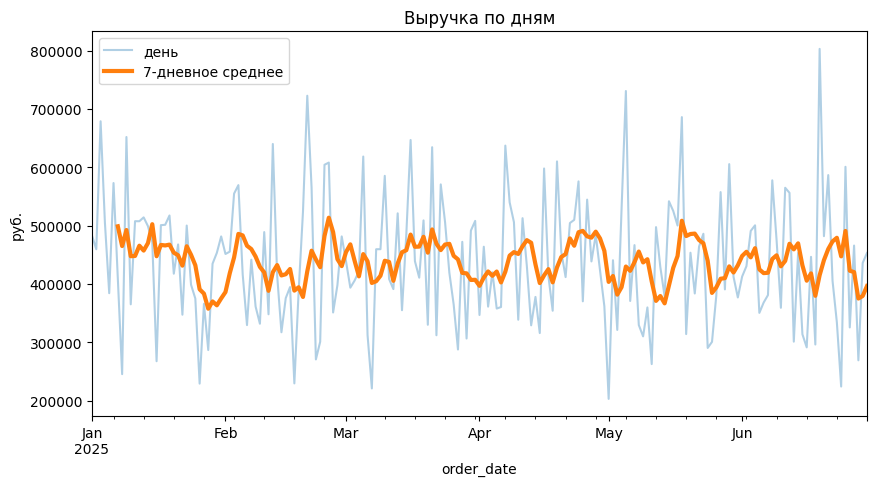

In [40]:
ax = daily_revenue.plot(alpha=0.35, label="день")
daily_revenue.rolling(7).mean().plot(ax=ax, linewidth=3, label="7-дневное среднее")
ax.set_title("Выручка по дням")
ax.set_ylabel("руб.")
ax.legend()

`resample("D")` собирает данные по дням, `resample("W")` — по неделям, `resample("M")` — по месяцам. Скользящее среднее через `.rolling(7).mean()` сглаживает шум и помогает увидеть тренд.

## Pandas и машинное обучение

Модель машинного обучения почти никогда не работает с “сырой” бизнесовой таблицей напрямую. Ей нужна матрица признаков `X`, где строки — объекты, а столбцы — числовые признаки, и целевая переменная `y`, которую мы хотим предсказывать.

Pandas помогает сделать самый важный подготовительный слой:

- собрать признаки из разных колонок и таблиц;
- превратить даты в понятные признаки: день недели, месяц, возраст объекта;
- закодировать категории числами;
- проверить пропуски и выбросы;
- отделить признаки от целевой переменной;
- передать результат в NumPy, scikit-learn, CatBoost, PyTorch или другую ML-библиотеку.

На практике качество этих шагов часто влияет на результат модели сильнее, чем выбор конкретного алгоритма.

In [41]:
orders_ml = orders.assign(
    is_large_order=(orders["revenue"] >= orders["revenue"].quantile(0.75)).astype(int),
    order_weekday=orders["order_date"].dt.dayofweek,
    order_month=orders["order_date"].dt.month,
)

features = orders_ml[
    [
        "quantity",
        "price",
        "discount",
        "delivery_days",
        "order_weekday",
        "order_month",
        "category",
        "channel",
        "federal_district",
    ]
]

X = pd.get_dummies(
    features,
    columns=["category", "channel", "federal_district"],
    dtype=int,
)
y = orders_ml["is_large_order"]

X.head()

,quantity,price,discount,delivery_days,order_weekday,order_month,category_Авто,category_Детские товары,category_Дом и ремонт,category_Одежда,category_Услуги,category_Хобби и спорт,category_Электроника,channel_call_center,channel_mobile_app,channel_partner,channel_web,federal_district_Дальневосточный,federal_district_Приволжский,federal_district_Северо-Западный,federal_district_Северо-Кавказский,federal_district_Сибирский,federal_district_Уральский,federal_district_Центральный,federal_district_Южный
0,2,4230,0.00,8,2,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0
1,1,5240,0.00,2,2,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
2,1,4070,0.05,4,2,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
3,1,4420,0.10,3,2,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
4,2,6190,0.00,2,2,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0


`pd.get_dummies` делает one-hot encoding: каждая категория превращается в отдельный бинарный столбец. Например, модель не понимает строку `"Электроника"`, но понимает числовой признак `category_Электроника`, равный 0 или 1.

Целевая переменная `y` в примере отвечает на вопрос: “является ли заказ крупным?”. В реальных задачах это может быть вероятность возврата, риск оттока, цена квартиры, класс документа, прогноз спроса или время доставки.

In [42]:
X_matrix = X.to_numpy()
y_vector = y.to_numpy()

X_matrix.shape, y_vector.shape

((6000, 25), (6000,))

In [43]:
rng = np.random.default_rng(42)
is_train = rng.random(len(X)) < 0.8

X_train, X_test = X.loc[is_train], X.loc[~is_train]
y_train, y_test = y.loc[is_train], y.loc[~is_train]

X_train.shape, X_test.shape, y_train.mean().round(3), y_test.mean().round(3)

((4827, 25), (1173, 25), 0.244, 0.276)

Разделение на train/test нужно, чтобы проверять модель на данных, которые она не видела при обучении. Без этого легко получить красивую метрику в ноутбуке и плохой результат в реальном продукте.

Многие ML-алгоритмы внутри сводятся к операциям над матрицами: умножениям, суммам, расстояниям, скалярным произведениям. Обычно мы не пишем эти операции вручную, но полезно понимать, что после pandas-подготовки таблица становится числовой матрицей.

In [44]:
X_numeric = X.astype(float)
X_centered = X_numeric - X_numeric.mean()

feature_covariance = X_centered.T @ X_centered / (len(X_centered) - 1)
feature_covariance.iloc[:5, :5]

,quantity,price,discount,delivery_days,order_weekday
quantity,0.378048,-4.342298e+01,0.000222,0.016495,0.004512
price,-43.422984,7.597608e+07,-4.657353,1.489155,-5.718300
discount,0.000222,-4.657353e+00,0.002009,0.000292,-0.001268
delivery_days,0.016495,1.489155e+00,0.000292,3.028195,-0.008003
order_weekday,0.004512,-5.718300e+00,-0.001268,-0.008003,3.982656


Такая матрица ковариаций показывает, как признаки меняются вместе. Это не замена обучению модели, но хороший пример того, почему аккуратная работа с таблицами, типами и матрицами — фундамент для машинного обучения.

## Визуализация

График нужен не для украшения, а для проверки гипотезы и коммуникации результата. В pandas многие графики строятся прямо из `DataFrame` или `Series`, потому что под капотом используется matplotlib.

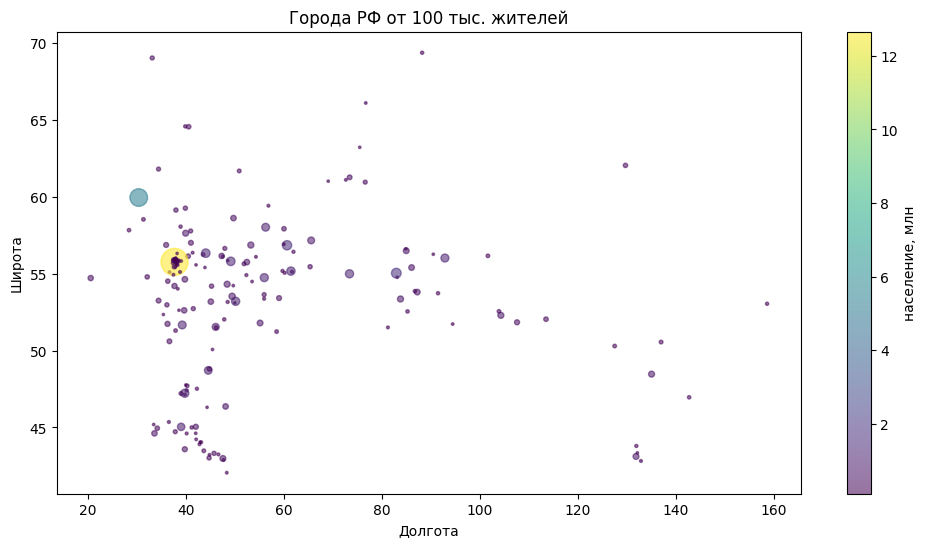

In [49]:
plot_data = towns_extended.query("population >= 100")

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(
    plot_data["lon"],
    plot_data["lat"],
    s=plot_data["population_mln"] * 30,
    c=plot_data["population_mln"],
    alpha=0.55,
    cmap="viridis",
)
ax.set_title("Города РФ от 100 тыс. жителей")
ax.set_xlabel("Долгота")
ax.set_ylabel("Широта")
plt.colorbar(scatter, ax=ax, label="население, млн")

Text(0.5, 0, 'руб.')

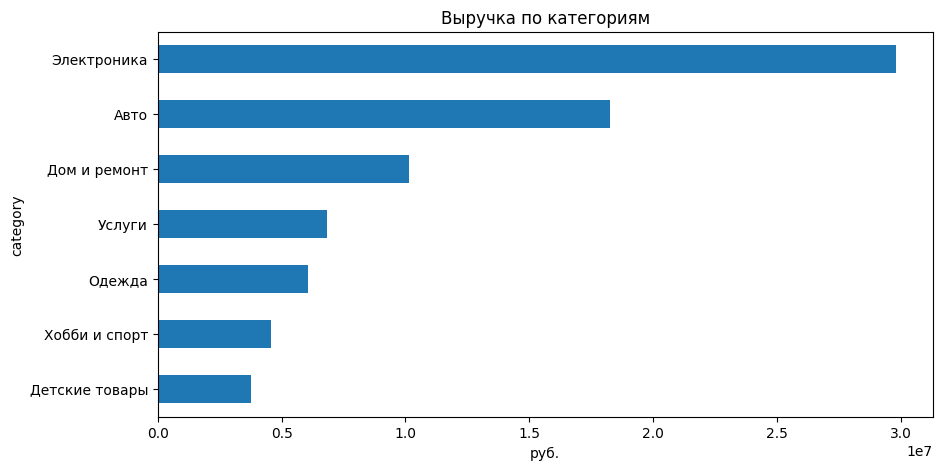

In [46]:
category_stats.sort_values("revenue")["revenue"].plot(
    kind="barh",
    title="Выручка по категориям",
)
plt.xlabel("руб.")

## Что важно вынести

Pandas — это инструмент для движения от сырой таблицы к решению:

- прочитать и проверить данные;
- выбрать нужные строки и признаки;
- аккуратно обработать пропуски;
- соединить источники;
- посчитать метрики;
- посмотреть динамику во времени;
- показать результат графиком или сводной таблицей.

Когда вы видите новый датасет, полезно начинать не с метода pandas, а с вопроса: “какое решение я хочу принять по этим данным?”. Тогда код становится осмысленным.